In [1]:
### ARTS as the line-by-line code
import os
# set global variables BEFORE importing ARTS
os.environ['ARTS_DATA_PATH'] = '../../arts-cat-data-2.6.14:../../arts-xml-data-2.6.14'

import pyarts
from pyarts.arts import convert
# the fluxsim module
import FluxSimulator as fsm
import seaborn as sns


# helper packages
import numpy as np
import xarray as xr
from scipy.constants import speed_of_light as c
import matplotlib.pyplot as plt

import typhon
import typhon.constants as tpc
import pandas as pd

from scipy.optimize import minimize

from cycler import cycler

In [2]:
ddq_sw = xr.open_dataset('/homedata/pczarnec/ddq-implementation-sprint/DDQ configurations/DDQ_SW_source.h5', engine = "netcdf4").compute()
ddq_lw = xr.open_dataset('/homedata/pczarnec/ddq-implementation-sprint/DDQ configurations/DDQ_LW.h5', engine = "netcdf4").compute()

getfattr: /homedata/pczarnec/ddq-implementation-sprint/DDQ: No such file or directory
getfattr: configurations/DDQ_SW_source.h5: No such file or directory
getfattr: /homedata/pczarnec/ddq-implementation-sprint/DDQ: No such file or directory
getfattr: configurations/DDQ_LW.h5: No such file or directory


In [3]:
### SW


In [4]:
profiles = xr.open_dataset('rfmip_expts.nc').isel(layer = slice(None, None, -1), level = slice(None, None, -1))
profiles

<xarray.Dataset> Size: 2MB
Dimensions:                 (site: 100, layer: 60, level: 61, expt: 18)
Dimensions without coordinates: site, layer, level, expt
Data variables: (12/20)
    pressure_layer          (site, layer) float32 24kB ...
    pressure_level          (site, level) float32 24kB ...
    surface_emissivity      (site) float32 400B ...
    surface_albedo          (site) float32 400B ...
    solar_zenith_angle      (site) float32 400B ...
    total_solar_irradiance  (site) float32 400B ...
    ...                      ...
    CFC12                   (expt) float32 72B ...
    CO2                     (expt) float32 72B ...
    CFC11                   (expt) float32 72B ...
    N2O                     (expt) float32 72B ...
    CH4                     (expt) float32 72B ...
    N_per_m2_dry            (site, layer, expt) float32 432kB ...
Attributes: (12/25)
    title:               Atmospheric conditions for off-line radiative transf...
    institution_id:      UColorado
    institution:         University of Colorado, Boulder, CO 80309, USA
    activity_id:         input4MIPs
    Conventions:         CF-1.6
    creation_date:       2019-03-20 16:07:21-0400
    ...                  ...
    nominal_resolution:  10 km
    target_mip:          RFMIP
    variable_id:         multiple
    grid_label:          none
    tracking_id:         hdl:21.14100/f379c294-f7bb-442d-bca7-64661d60780e
    license:             Atmospheric condition data for RFMIP produced by the...

In [5]:
results_all = []

for exp in profiles.expt.data:
    profile = profiles.isel(expt = exp)

    results_xrs_exp = []

    for atm_idx in range(len((profile.site.data))):
        H2O_level =  np.interp(profile.pressure_level.data[atm_idx, ::-1], profile.pressure_layer.data[atm_idx, ::-1], profile.H2O.data[atm_idx, ::-1])[::-1]
        O3_level = np.interp(profile.pressure_level.data[atm_idx, ::-1], profile.pressure_layer.data[atm_idx, ::-1], profile.O3.data[atm_idx, ::-1])[::-1]
        pressure = profile.pressure_level.data[atm_idx, :].copy()
        pressure[-1] = np.max([pressure[-1], 1])
        atm_field = fsm.generate_gridded_field_from_profiles(
            pressure.tolist(), # pressure, in units Pa; must be a list
            profile.temperature_level.data[atm_idx, :], # temerpature, in units K
            gases={"H2O": H2O_level,
                "CO2": profile.CO2.data, 
                "O3": O3_level,
                "CH4": profile.CH4.data,
                "N2O": profile.N2O.data,
                "O2": profile.O2.data,
                "N2": profile.N2.data,
                "CFC12" : profile.CFC12.data,
                "CFC11" : profile.CFC11.data
                },
            )

        tsurf = profile.surface_temperature.data[atm_idx]
        alt = atm_field[1][0][0][0]
        sza = profile.solar_zenith_angle.data[atm_idx]
        if (sza <= -90) or (sza >= 90):
            sza = 89.99

        geo = [sza, 0]
        sun = [1.49331100e11, 0.0, 0.0] # moved so that insolation matches LMDZ
        alb = [profile.surface_albedo.data[atm_idx]]

        FluxSimulator_SW = fsm.FluxSimulator("sw")
        FluxSimulator_SW.ws.disort_aux_vars = ["Layer optical thickness", "Single scattering albedo", "Asymmetry parameter"]

        FluxSimulator_SW.ws.f_grid = convert.kaycm2freq(ddq_sw.S.data)
        FluxSimulator_SW.set_paths(lut_path='/homedata/pczarnec/ddq-implementation-sprint/DDQ configurations/LUTs/DDQ_sw')
        FluxSimulator_SW.set_species(
            ["H2O, H2O-SelfContCKDMT400, H2O-ForeignContCKDMT400",
                "O2-*-1e12-1e99,O2-CIAfunCKDMT100",
                "N2, N2-CIAfunCKDMT252, N2-CIArotCKDMT252",
                "CH4",
                "CO2, CO2-CKDMT252",
                "N2O",
                "O3",
                "O3-XFIT",    
                ]
        )

        FluxSimulator_SW.emission = 0
        FluxSimulator_SW.gas_scattering = True

        FluxSimulator_SW.sunspectrumtype = '/homedata/pczarnec/arts-xml-data-2.6.14/star/Sun/solar_spectrum_July_2008.xml'
        FluxSimulator_SW.set_sun()
        FluxSimulator_SW.scale_sun_to_specific_TSI_at_TOA(profile.total_solar_irradiance.data[atm_idx], geo[0], geo[1], atm_field[1][-1][0][0])

        FluxSimulator_SW.quadrature_weights = ddq_sw.W.data * c * 100

        result = FluxSimulator_SW.flux_simulator_single_profile(
            atm_field,
            tsurf,
            alt,
            alb,
            geo,
        )

        atm_xr = xr.Dataset(
            data_vars = dict(
                layer_optical_thickness = (["S", "layer"], result["aux_var_clearsky"][0]),
                single_scattering_albedo = (["S", "layer"], result["aux_var_clearsky"][1]),
                asymmetry_parameter = (["S", "layer"], result["aux_var_clearsky"][2]),
                spec_flux_clearsky_up =  (["S", "level"], result["spectral_flux_clearsky_up"]),
                spec_flux_clearsky_down =  (["S", "level"], result["spectral_flux_clearsky_down"]),
                DDQ_flux_clearsky_up =  (["level"], result["flux_clearsky_up"]),
                DDQ_flux_clearsky_down =  (["level"], result["flux_clearsky_down"]),
            ),
            coords = dict(
                S = ddq_sw.S.data,
                layer = profile.layer,
                level = profile.level,
            )
        )

        results_xrs_exp.append(atm_xr)
    
    results_xrs_exp_xr = xr.concat(results_xrs_exp, 'site')

    results_all.append(results_xrs_exp_xr)

results_final = xr.concat(results_all, 'expt')

setting up absorption...

...using stored LUT

starting calculation...

setting up absorption...

...using stored LUT

starting calculation...



Start disort
Start disort


setting up absorption...

...using stored LUT

starting calculation...

setting up absorption...

...using stored LUT

starting calculation...



Start disort
Start disort


setting up absorption...

...using stored LUT

starting calculation...

setting up absorption...

...using stored LUT

starting calculation...



...

Start disort
Start disort


setting up absorption...

...using stored LUT

starting calculation...

setting up absorption...

...using stored LUT

starting calculation...



Start disort
Start disort


setting up absorption...

...using stored LUT

starting calculation...

setting up absorption...

...using stored LUT

starting calculation...



Start disort
Start disort


In [6]:
results_final.to_netcdf('DDQ_RFMIP_SW.nc')

In [10]:
profiles

<xarray.Dataset> Size: 2MB
Dimensions:                 (site: 100, layer: 60, level: 61, expt: 18)
Dimensions without coordinates: site, layer, level, expt
Data variables: (12/20)
    pressure_layer          (site, layer) float32 24kB ...
    pressure_level          (site, level) float32 24kB ...
    surface_emissivity      (site) float32 400B ...
    surface_albedo          (site) float32 400B ...
    solar_zenith_angle      (site) float32 400B ...
    total_solar_irradiance  (site) float32 400B ...
    ...                      ...
    CFC12                   (expt) float32 72B ...
    CO2                     (expt) float32 72B ...
    CFC11                   (expt) float32 72B ...
    N2O                     (expt) float32 72B ...
    CH4                     (expt) float32 72B ...
    N_per_m2_dry            (site, layer, expt) float32 432kB ...
Attributes: (12/25)
    title:               Atmospheric conditions for off-line radiative transf...
    institution_id:      UColorado
    institution:         University of Colorado, Boulder, CO 80309, USA
    activity_id:         input4MIPs
    Conventions:         CF-1.6
    creation_date:       2019-03-20 16:07:21-0400
    ...                  ...
    nominal_resolution:  10 km
    target_mip:          RFMIP
    variable_id:         multiple
    grid_label:          none
    tracking_id:         hdl:21.14100/f379c294-f7bb-442d-bca7-64661d60780e
    license:             Atmospheric condition data for RFMIP produced by the...

In [7]:
results_all = []

for exp in profiles.expt.data:
    profile = profiles.isel(expt = exp)

    results_xrs_exp = []

    for atm_idx in range(len((profile.site.data))):
        H2O_level =  np.interp(profile.pressure_level.data[atm_idx, ::-1], profile.pressure_layer.data[atm_idx, ::-1], profile.H2O.data[atm_idx, ::-1])[::-1]
        O3_level = np.interp(profile.pressure_level.data[atm_idx, ::-1], profile.pressure_layer.data[atm_idx, ::-1], profile.O3.data[atm_idx, ::-1])[::-1]
        pressure = profile.pressure_level.data[atm_idx, :].copy()
        pressure[-1] = np.max([pressure[-1], 1])
        atm_field = fsm.generate_gridded_field_from_profiles(
            pressure.tolist(), # pressure, in units Pa; must be a list
            profile.temperature_level.data[atm_idx, :], # temerpature, in units K
            gases={"H2O": H2O_level,
                "CO2": profile.CO2.data, 
                "O3": O3_level,
                "CH4": profile.CH4.data,
                "N2O": profile.N2O.data,
                "O2": profile.O2.data,
                "N2": profile.N2.data,
                "CFC12" : profile.CFC12.data,
                "CFC11" : profile.CFC11.data
                },
            )

        tsurf = profile.surface_temperature.data[atm_idx]
        alt = atm_field[1][0][0][0]
        sza = profile.solar_zenith_angle.data[atm_idx]
        if (sza <= -90) or (sza >= 90):
            sza = 89.99

        geo = [sza, 0]
        sun = [1.49331100e11, 0.0, 0.0] # moved so that insolation matches LMDZ
        alb = [1 - profile.surface_emissivity.data[atm_idx]]

        FluxSimulator_LW = fsm.FluxSimulator("lw")
        FluxSimulator_LW.ws.disort_aux_vars = ["Layer optical thickness", "Single scattering albedo", "Asymmetry parameter"]

        FluxSimulator_LW.ws.f_grid = convert.kaycm2freq(ddq_lw.S.data)
        FluxSimulator_LW.set_paths(lut_path='/homedata/pczarnec/ddq-implementation-sprint/DDQ configurations/LUTs/DDQ_lw')
        FluxSimulator_LW.set_species(
            [
            "O2, O2-CIAfunCKDMT100",
                "H2O, H2O-SelfContCKDMT400, H2O-ForeignContCKDMT400",
                "O3",
                "CO2, CO2-CKDMT252",
                "N2, N2-CIAfunCKDMT252, N2-CIArotCKDMT252",
                "N2O",
                "CH4", 
                "CFC11-XFIT", "CFC12-XFIT"
            ]
        )

        FluxSimulator_LW.gas_scattering = False # True

        FluxSimulator_LW.quadrature_weights = ddq_lw.W.data * c * 100

        result = FluxSimulator_LW.flux_simulator_single_profile(
            atm_field,
            tsurf,
            alt,
            alb,
            geo,
        )

        atm_xr = xr.Dataset(
            data_vars = dict(
                layer_optical_thickness = (["S", "layer"], result["aux_var_clearsky"][0]),
                single_scattering_albedo = (["S", "layer"], result["aux_var_clearsky"][1]),
                asymmetry_parameter = (["S", "layer"], result["aux_var_clearsky"][2]),
                spec_flux_clearsky_up =  (["S", "level"], result["spectral_flux_clearsky_up"]),
                spec_flux_clearsky_down =  (["S", "level"], result["spectral_flux_clearsky_down"]),
                DDQ_flux_clearsky_up =  (["level"], result["flux_clearsky_up"]),
                DDQ_flux_clearsky_down =  (["level"], result["flux_clearsky_down"]),
            ),
            coords = dict(
                S = ddq_lw.S.data,
                layer = profile.layer,
                level = profile.level,
            )
        )

        results_xrs_exp.append(atm_xr)
    
    results_xrs_exp_xr = xr.concat(results_xrs_exp, 'site')

    results_all.append(results_xrs_exp_xr)

results_final = xr.concat(results_all, 'expt')

setting up absorption...

...using stored LUT

starting calculation...



Start disort
Start disort


setting up absorption...

...using stored LUT

starting calculation...

setting up absorption...

...using stored LUT

starting calculation...



Start disort
Start disort


setting up absorption...

...using stored LUT

starting calculation...

setting up absorption...

...using stored LUT

starting calculation...



...

Start disort
Start disort


setting up absorption...

...using stored LUT

starting calculation...

setting up absorption...

...using stored LUT

starting calculation...



Start disort


setting up absorption...

...using stored LUT

starting calculation...



Start disort


In [8]:
results_final.to_netcdf('DDQ_RFMIP_LW.nc')

In [3]:
### example plots

ddq_rfmip_lw = xr.open_dataset('DDQ_RFMIP_LW.nc')
ddq_rfmip_sw = xr.open_dataset('DDQ_RFMIP_SW.nc')
ddq_rfmip_sw

<xarray.Dataset> Size: 280MB
Dimensions:                   (expt: 18, site: 100, S: 64, layer: 60, level: 61)
Coordinates:
  * S                         (S) float64 512B 2.144e+03 2.411e+03 ... 4.839e+04
  * layer                     (layer) int64 480B 0 1 2 3 4 5 ... 55 56 57 58 59
  * level                     (level) int64 488B 0 1 2 3 4 5 ... 56 57 58 59 60
Dimensions without coordinates: expt, site
Data variables:
    layer_optical_thickness   (expt, site, S, layer) float64 55MB ...
    single_scattering_albedo  (expt, site, S, layer) float64 55MB ...
    asymmetry_parameter       (expt, site, S, layer) float64 55MB ...
    spec_flux_clearsky_up     (expt, site, S, level) float64 56MB ...
    spec_flux_clearsky_down   (expt, site, S, level) float64 56MB ...
    DDQ_flux_clearsky_up      (expt, site, level) float64 878kB ...
    DDQ_flux_clearsky_down    (expt, site, level) float64 878kB ...

In [5]:
profiles

<xarray.Dataset> Size: 2MB
Dimensions:                 (site: 100, layer: 60, level: 61, expt: 18)
Dimensions without coordinates: site, layer, level, expt
Data variables: (12/20)
    pressure_layer          (site, layer) float32 24kB ...
    pressure_level          (site, level) float32 24kB ...
    surface_emissivity      (site) float32 400B ...
    surface_albedo          (site) float32 400B ...
    solar_zenith_angle      (site) float32 400B ...
    total_solar_irradiance  (site) float32 400B ...
    ...                      ...
    CFC12                   (expt) float32 72B ...
    CO2                     (expt) float32 72B ...
    CFC11                   (expt) float32 72B ...
    N2O                     (expt) float32 72B ...
    CH4                     (expt) float32 72B ...
    N_per_m2_dry            (site, layer, expt) float32 432kB ...
Attributes: (12/25)
    title:               Atmospheric conditions for off-line radiative transf...
    institution_id:      UColorado
    institution:         University of Colorado, Boulder, CO 80309, USA
    activity_id:         input4MIPs
    Conventions:         CF-1.6
    creation_date:       2019-03-20 16:07:21-0400
    ...                  ...
    nominal_resolution:  10 km
    target_mip:          RFMIP
    variable_id:         multiple
    grid_label:          none
    tracking_id:         hdl:21.14100/f379c294-f7bb-442d-bca7-64661d60780e
    license:             Atmospheric condition data for RFMIP produced by the...

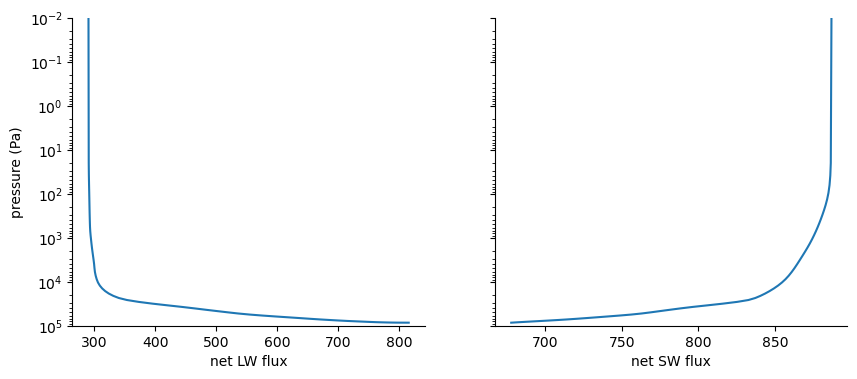

In [20]:
site_idx = 0
expt_idx = 0
fig, axes = plt.subplots(1, 2, figsize = (10, 4), sharey = True)
axes[0].semilogy(ddq_rfmip_lw.DDQ_flux_clearsky_up.isel(site = site_idx, expt = expt_idx) - 
             ddq_rfmip_lw.DDQ_flux_clearsky_down.isel(site = site_idx, expt = expt_idx), 
             profiles.pressure_level.isel(site = site_idx))
axes[0].set_ylim([100000, 0.01])
axes[0].set_ylabel("pressure (Pa)")
axes[0].set_xlabel("net LW flux")

axes[1].semilogy(ddq_rfmip_sw.DDQ_flux_clearsky_up.isel(site = site_idx, expt = expt_idx) - 
             ddq_rfmip_sw.DDQ_flux_clearsky_down.isel(site = site_idx, expt = expt_idx), 
             profiles.pressure_level.isel(site = site_idx))
axes[1].set_xlabel("net SW flux")

sns.despine()

plt.show()